# FusedLinearCrossEntropy: Verifying Memory Reduction

We have discussed the concepts of checkpointing, chunking, and gradient-in-forward to avoid materialization of logits as well as recomputation. The implementation is quite complex, so I will leave it for your self-study. In this notebook, we will verify if FusedLinearCrossEntropy can actually reduce peak memory usage while maintaining comparable speed.

### Ensure you are using GPU by running `nvidia-smi`

In [ ]:
!nvidia-smi

Wed Aug 21 05:07:27 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

### Install liger-kernel for FusedLinearCrossEntropy implementation

In [ ]:
!pip install liger-kernel

### Benchmark FusedLinearCrossEntropy

Compare FusedLinearCrossEntropy with Hugging Face implementation for speed and memory

In [ ]:
import os

import torch
import triton

from liger_kernel.transformers.fused_linear_cross_entropy import (
    LigerFusedLinearCrossEntropyLoss,
)


class TorchLMHeadCE(torch.nn.Module):
    """Ground truth implementation of the linear fused with torch based cross entropy loss.

    :param H: hidden size
    :param V: vocab size
    :param ignore_index: index to ignore
    :param reduction: reduction method
    """

    def __init__(self, H: int, V: int, dtype: torch.dtype, ignore_index: int = -100):
        super().__init__()
        self.lin = torch.nn.Linear(
            in_features=H, out_features=V, bias=False, dtype=dtype
        )
        self.ce_loss = torch.nn.CrossEntropyLoss(
            ignore_index=ignore_index, reduction="mean"
        )

    def forward(self, x, y):
        logits = self.lin(x)
        return self.ce_loss(logits, y)


class LigerLMHeadCE(torch.nn.Module):
    def __init__(self, H: int, V: int, dtype: torch.dtype, ignore_index: int = -100):
        super().__init__()
        self.lin = torch.nn.Linear(
            in_features=H, out_features=V, bias=False, dtype=dtype
        )
        self.ce_loss = LigerFusedLinearCrossEntropyLoss(
            ignore_index=ignore_index, reduction="mean"
        )

    def forward(self, x, y):
        return self.ce_loss(self.lin.weight, x, y)

Running benchmark with BT=1024, H=4096, V=128256, dtype=torch.float32 provider=liger
Running benchmark with BT=1024, H=4096, V=128256, dtype=torch.float32 provider=huggingface
Running benchmark with BT=2048, H=4096, V=128256, dtype=torch.float32 provider=liger
Running benchmark with BT=2048, H=4096, V=128256, dtype=torch.float32 provider=huggingface
Running benchmark with BT=4096, H=4096, V=128256, dtype=torch.float32 provider=liger
Running benchmark with BT=4096, H=4096, V=128256, dtype=torch.float32 provider=huggingface


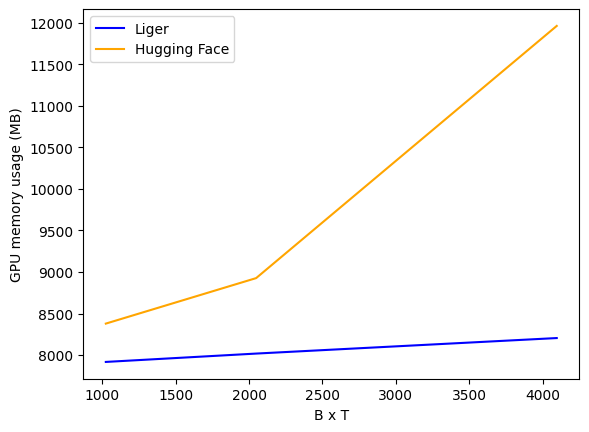

fused-linear-cross-entropy-memory-benchmark:
       BT        Liger  Hugging Face
0  1024.0  7918.136719   8379.258789
1  2048.0  8018.610937   8926.666602
2  4096.0  8205.371875  11961.482227


In [ ]:

def test_memory(func, _iter):
    total_mem = []

    for _ in range(_iter):
        torch.cuda.memory.reset_peak_memory_stats()
        func()
        mem = torch.cuda.max_memory_allocated() / (2**20)
        total_mem.append(mem)

    return sum(total_mem) / len(total_mem)

@triton.testing.perf_report(
    [
        triton.testing.Benchmark(
            x_names=["BT"],
            x_vals=[2**i for i in range(10, 13)], # 1024, 2048, 4096
            xlabel="B x T",
            line_arg="provider",
            line_vals=["liger", "huggingface"],
            line_names=["Liger", "Hugging Face"],
            styles=[
                ("blue", "solid"),
                ("orange", "solid"),
            ],
            ylabel="GPU memory usage (MB)",
            plot_name="fused-linear-cross-entropy-memory-benchmark",
            args={"H": 4096, "V": 128256, "dtype": torch.float32},
        )
    ]
)
def bench_memory_cross_entropy(BT, H, V, provider, dtype, device="cuda"):
    print(
        f"Running benchmark with BT={BT}, H={H}, V={V}, dtype={dtype} provider={provider}"
    )
    torch_lm_head_ce = TorchLMHeadCE(H=H, V=V, dtype=dtype).to(device)
    liger_lm_head_ce = LigerLMHeadCE(H=H, V=V, dtype=dtype).to(device)

    _input = torch.randn(BT, H, requires_grad=True, dtype=dtype, device=device)
    target = torch.randint(V, (BT, 1), dtype=torch.long, device=device).squeeze(1)

    def fwd():
        if provider == "liger":
            return liger_lm_head_ce(_input, target)
        elif provider == "huggingface":
            return torch_lm_head_ce(_input, target)

    def full():
        y = fwd()
        y.backward()

    mem = test_memory(full, _iter=10)
    return mem


bench_memory_cross_entropy.run(show_plots=True, print_data=True)

Running benchmark with BT=1024, H=4096, V=128256, dtype=torch.float32 provider=liger
Running benchmark with BT=1024, H=4096, V=128256, dtype=torch.float32 provider=huggingface
Running benchmark with BT=2048, H=4096, V=128256, dtype=torch.float32 provider=liger
Running benchmark with BT=2048, H=4096, V=128256, dtype=torch.float32 provider=huggingface
Running benchmark with BT=4096, H=4096, V=128256, dtype=torch.float32 provider=liger
Running benchmark with BT=4096, H=4096, V=128256, dtype=torch.float32 provider=huggingface


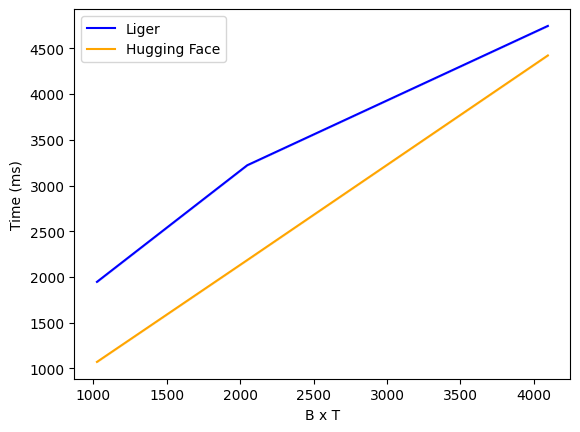

fused-linear-cross-entropy-speed-benchmark:
       BT        Liger  Hugging Face
0  1024.0  1945.992676   1070.364746
1  2048.0  3221.621094   2184.357910
2  4096.0  4745.461914   4422.612793


In [ ]:
@triton.testing.perf_report(
    [
        triton.testing.Benchmark(
            x_names=["BT"],
            x_vals=[2**i for i in range(10, 13)], # 1024, 2048, 4096
            xlabel="B x T",
            line_arg="provider",
            line_vals=["liger", "huggingface"],
            line_names=["Liger", "Hugging Face"],
            styles=[
                ("blue", "solid"),
                ("orange", "solid"),
            ],
            ylabel="Time (ms)",
            plot_name="fused-linear-cross-entropy-speed-benchmark",
            args={"H": 4096, "V": 128256, "dtype": torch.float32},
        )
    ]
)
def bench_speed_cross_entropy(BT, H, V, provider, dtype, device="cuda"):
    print(
        f"Running benchmark with BT={BT}, H={H}, V={V}, dtype={dtype} provider={provider}"
    )
    torch_lm_head_ce = TorchLMHeadCE(H=H, V=V, dtype=dtype).to(device)
    liger_lm_head_ce = LigerLMHeadCE(H=H, V=V, dtype=dtype).to(device)

    _input = torch.randn(BT, H, requires_grad=True, dtype=dtype, device=device)
    target = torch.randint(V, (BT, 1), dtype=torch.long, device=device).squeeze(1)

    def fwd():
        if provider == "liger":
            return liger_lm_head_ce(_input, target)
        elif provider == "huggingface":
            return torch_lm_head_ce(_input, target)

    def full():
        y = fwd()
        y.backward()

    quantiles = [0.5, 0.2, 0.8]

    ms, min_ms, max_ms = triton.testing.do_bench(full, quantiles=quantiles, rep=100)
    return ms, min_ms, max_ms


bench_speed_cross_entropy.run(show_plots=True, print_data=True)

Tue Aug 20 19:02:18 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   73C    P0              70W /  70W |  14283MiB / 15360MiB |    100%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

### Conclusion

1. We can observe significant memory advantages for our implementation because we don't materialize full logits at any given moment.
2. The speed is slightly slower, but because the lm_head + cross_entropy is only executed once compared with N times for the transformers block, the overhead is tolerable. It enables us to increase batch size, seq len, or turn off gradient checkpointing.